In [5]:
import numpy as np
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from DESolver import DESolver

from problems_ODEs import ProblemsODE
from problems_PDEs import ProblemsPDE

import seaborn as sns
sns.set_context("talk", font_scale=1.) # "talk"
TEND=0.2
KAPPA=np.asarray([1e+03,2e+03])

CFL = 0.4
Solving Advection Reaction 1D by using ARK2e


/opt/local/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Mass ini = 2.2542499999999994 and mass end = 2.1597843330548536


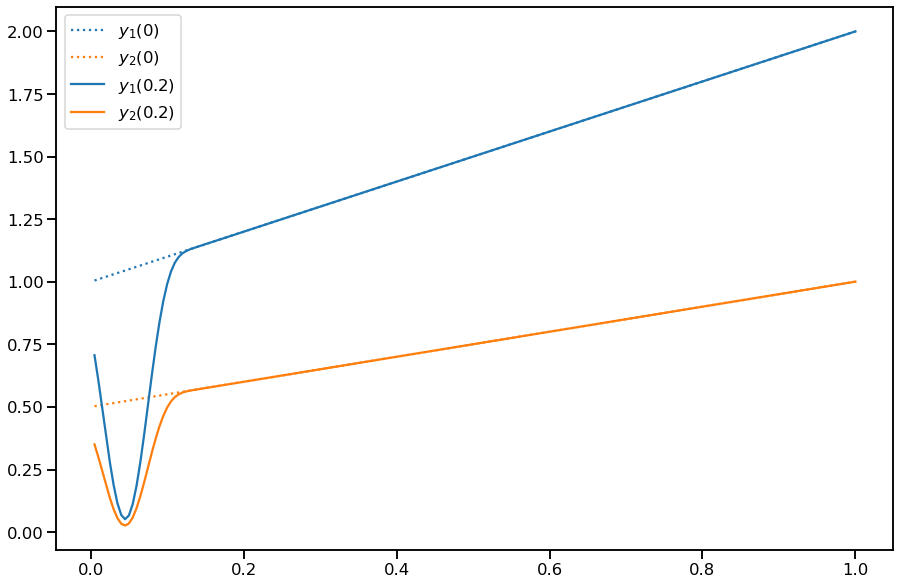

------------------------------------------
Current Method
Selected method type: ARK
Method coefficients:
A =
[[0.         0.         0.        ]
 [0.58578644 0.         0.        ]
 [0.02859548 0.97140452 0.        ]]
b =
[0.35355339 0.35355339 0.29289322]
c =
[0.         0.58578644 1.        ]
At =
[[0.         0.         0.        ]
 [0.29289322 0.29289322 0.        ]
 [0.35355339 0.35355339 0.29289322]]
bt =
[0.35355339 0.35355339 0.29289322]
ct =
[0.         0.58578644 1.        ]
------------------------------------------


In [7]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup={'mx':200,'n':2,'Flux':'linear-advection','Flux_c':1.,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':KAPPA,
                   's':np.asarray([0,1]),'alpha':np.asarray([1,0])}
rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection Reaction 1D',pde_problem_setup)#('Navier-Stokes2D')

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)


solver.set_method('ARK2e')
#solver.set_method('ARK-IMEX-MR4')
#solver.set_method('ARK-IMEX-Mix-1-1')


if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.002    
problem_setup['T_DURATION']['end']=TEND


print("CFL = {:}".format(pde_problem_setup['Flux_c']*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u,_,_,_=solver.get_trajectory_GLEE()
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))



#sol=u
unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
hy1=plt.plot(x_coord,y_ini[0,:],':',label=r'$y_1(0)$')
hy2=plt.plot(x_coord,y_ini[1,:],':',label=r'$y_2(0)$')

plt.plot(x_coord,y_end[0,:],'-',color=hy1[0].get_color(),label=r'$y_1({:g})$'.format(t[-1]))
plt.plot(x_coord,y_end[1,:],'-',color=hy2[0].get_color(),label=r'$y_2({:g})$'.format(t[-1]))

plt.legend()
plt.show()

solver.view_complete_status()

ARK11={'x_coord':x_coord,'y_end':y_end}


CFL = 0.4
Solving Advection Reaction 1D by using ARK2c


/opt/local/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Mass ini = 2.2542499999999994 and mass end = 1.6716828670490274


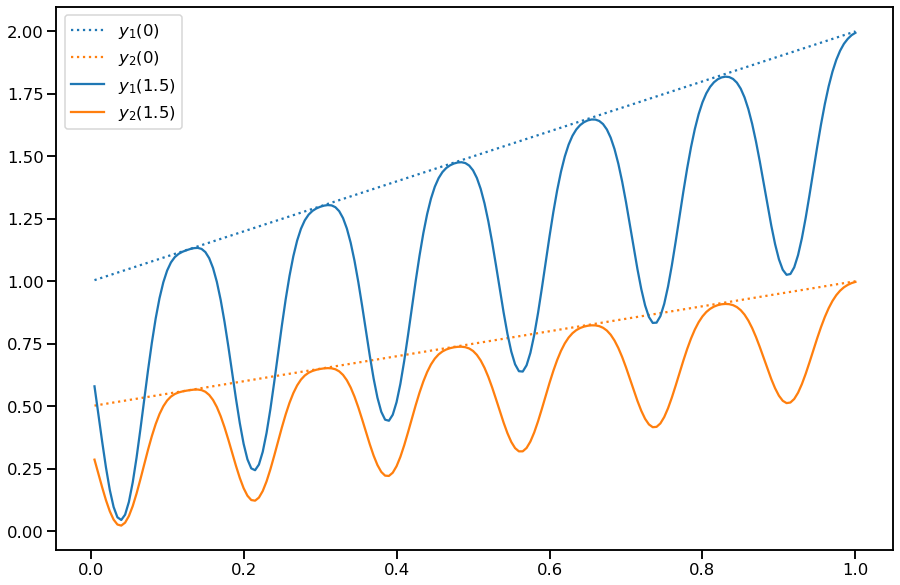

------------------------------------------
Current Method
Selected method type: ARK
Method coefficients:
A =
[[0.         0.         0.        ]
 [0.58578644 0.         0.        ]
 [0.5        0.5        0.        ]]
b =
[0.35355339 0.35355339 0.29289322]
c =
[0.         0.58578644 1.        ]
At =
[[0.         0.         0.        ]
 [0.29289322 0.29289322 0.        ]
 [0.35355339 0.35355339 0.29289322]]
bt =
[0.35355339 0.35355339 0.29289322]
ct =
[0.         0.58578644 1.        ]
------------------------------------------


In [3]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup={'mx':200,'n':2,'Flux':'linear-advection','Flux_c':1.,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':KAPPA,
                   's':np.asarray([0,1]),'alpha':np.asarray([1,0])}
rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection Reaction 1D',pde_problem_setup)#('Navier-Stokes2D')

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)


#solver.set_method('ARK2e')
#solver.set_method('ARK-IMEX-MR4')
solver.set_method('ARK2c')


if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.002    
problem_setup['T_DURATION']['end']=TEND


print("CFL = {:}".format(pde_problem_setup['Flux_c']*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u,_,_,_=solver.get_trajectory_GLEE()
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))



#sol=u
unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
hy1=plt.plot(x_coord,y_ini[0,:],':',label=r'$y_1(0)$')
hy2=plt.plot(x_coord,y_ini[1,:],':',label=r'$y_2(0)$')

plt.plot(x_coord,y_end[0,:],'-',color=hy1[0].get_color(),label=r'$y_1({:g})$'.format(t[-1]))
plt.plot(x_coord,y_end[1,:],'-',color=hy2[0].get_color(),label=r'$y_2({:g})$'.format(t[-1]))

plt.legend()
plt.show()

solver.view_complete_status()

ARK2c={'x_coord':x_coord,'y_end':y_end}


CFL = 0.4
Solving Advection Reaction 1D by using ARK-IMEX-Mix-2-1


/opt/local/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Mass ini = 2.2542499999999994 and mass end = 1.6716767290135455


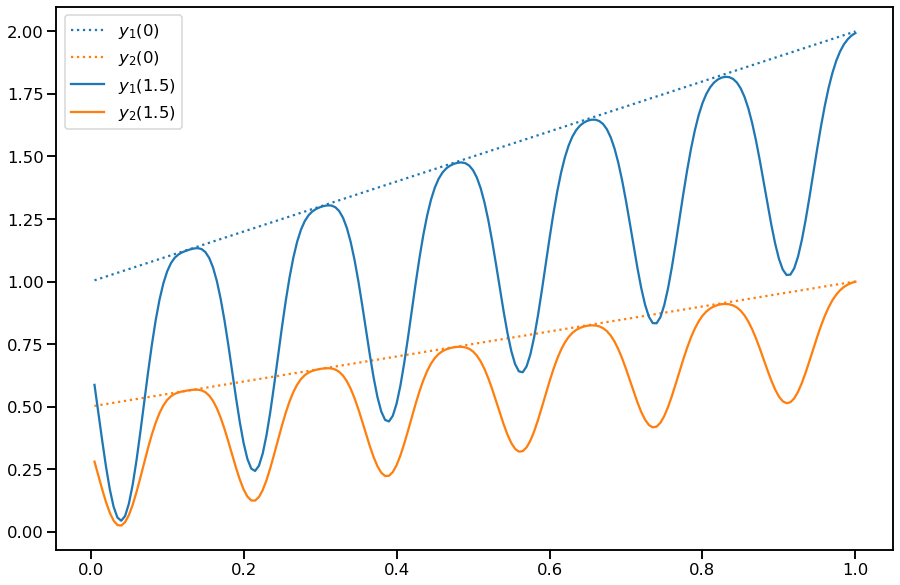

------------------------------------------
Current Method
Selected method type: ARK
Method coefficients:
A =
[[0. 0.]
 [1. 0.]]
b =
[0.5 0.5]
c =
[0. 1.]
At =
[[0. 0.]
 [1. 1.]]
bt =
[0.5 0.5]
ct =
[0. 2.]
------------------------------------------


In [4]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup={'mx':200,'n':2,'Flux':'linear-advection','Flux_c':1.,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':KAPPA,
                   's':np.asarray([0,1]),'alpha':np.asarray([1,0])}
rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection Reaction 1D',pde_problem_setup)#('Navier-Stokes2D')

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)


#solver.set_method('ARK2e')
#solver.set_method('ARK-IMEX-MR4')
solver.set_method('ARK-IMEX-Mix-2-1')


if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.002    
problem_setup['T_DURATION']['end']=TEND


print("CFL = {:}".format(pde_problem_setup['Flux_c']*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u,_,_,_=solver.get_trajectory_GLEE()
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))



#sol=u
unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
hy1=plt.plot(x_coord,y_ini[0,:],':',label=r'$y_1(0)$')
hy2=plt.plot(x_coord,y_ini[1,:],':',label=r'$y_2(0)$')

plt.plot(x_coord,y_end[0,:],'-',color=hy1[0].get_color(),label=r'$y_1({:g})$'.format(t[-1]))
plt.plot(x_coord,y_end[1,:],'-',color=hy2[0].get_color(),label=r'$y_2({:g})$'.format(t[-1]))

plt.legend()
plt.show()

solver.view_complete_status()

ARK21={'x_coord':x_coord,'y_end':y_end}


CFL = 0.4
Solving Advection Reaction 1D by using ARK-IMEX-Mix-2-2


/opt/local/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Mass ini = 2.2542499999999994 and mass end = 1.6716675620474961


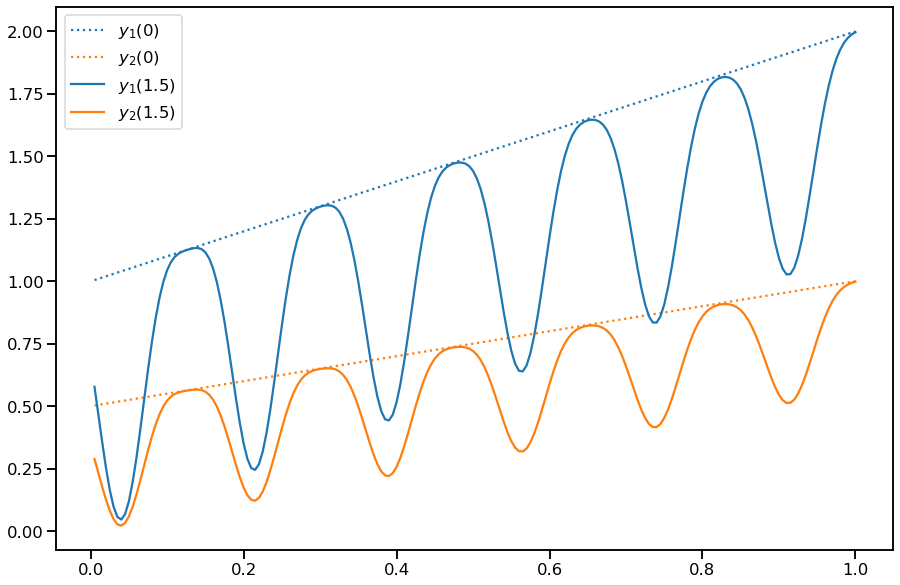

------------------------------------------
Current Method
Selected method type: ARK
Method coefficients:
A =
[[0. 0.]
 [1. 0.]]
b =
[0.5 0.5]
c =
[0. 1.]
At =
[[0.25       0.        ]
 [0.41666667 0.33333333]]
bt =
[0.5 0.5]
ct =
[0.25 0.75]
------------------------------------------


In [5]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup={'mx':200,'n':2,'Flux':'linear-advection','Flux_c':1.,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':KAPPA,
                   's':np.asarray([0,1]),'alpha':np.asarray([1,0])}
rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection Reaction 1D',pde_problem_setup)#('Navier-Stokes2D')

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)


#solver.set_method('ARK2e')
#solver.set_method('ARK-IMEX-MR4')
solver.set_method('ARK-IMEX-Mix-2-2')


if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.002    
problem_setup['T_DURATION']['end']=TEND


print("CFL = {:}".format(pde_problem_setup['Flux_c']*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u,_,_,_=solver.get_trajectory_GLEE()
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))



#sol=u
unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
hy1=plt.plot(x_coord,y_ini[0,:],':',label=r'$y_1(0)$')
hy2=plt.plot(x_coord,y_ini[1,:],':',label=r'$y_2(0)$')

plt.plot(x_coord,y_end[0,:],'-',color=hy1[0].get_color(),label=r'$y_1({:g})$'.format(t[-1]))
plt.plot(x_coord,y_end[1,:],'-',color=hy2[0].get_color(),label=r'$y_2({:g})$'.format(t[-1]))

plt.legend()
plt.show()

solver.view_complete_status()

ARK22={'x_coord':x_coord,'y_end':y_end}


CFL = 0.4
Solving Advection Reaction 1D by using ARK-IMEX-Mix-2-1-c


/opt/local/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Mass ini = 2.2542499999999994 and mass end = 1.6716962192320588


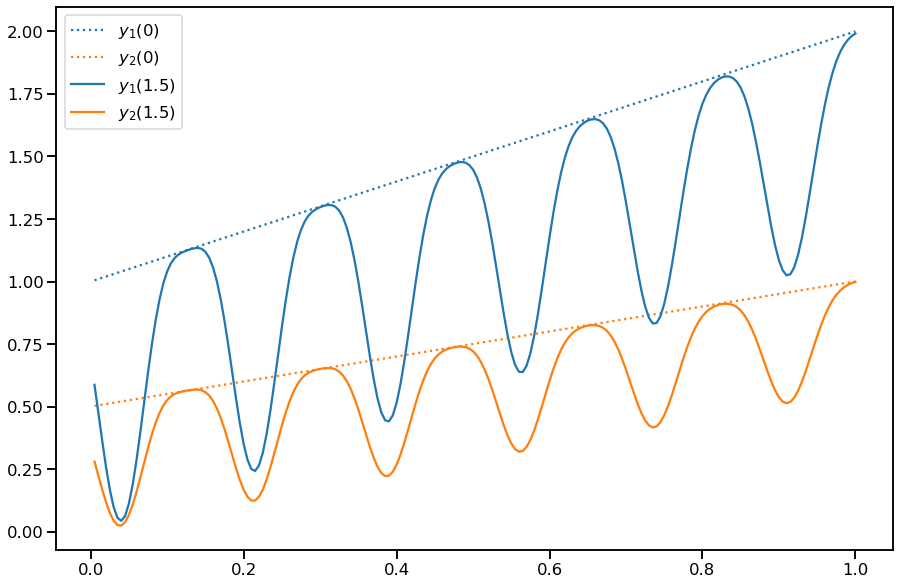

------------------------------------------
Current Method
Selected method type: ARK
Method coefficients:
A =
[[0.         0.         0.        ]
 [0.58578644 0.         0.        ]
 [0.5        0.5        0.        ]]
b =
[0.35355339 0.35355339 0.29289322]
c =
[0.         0.58578644 1.        ]
At =
[[0.         0.         0.        ]
 [0.         0.         0.        ]
 [1.20710678 1.20710678 1.        ]]
bt =
[0.35355339 0.35355339 0.29289322]
ct =
[0.         0.         3.41421356]
------------------------------------------


In [6]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup={'mx':200,'n':2,'Flux':'linear-advection','Flux_c':1.,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':KAPPA,
                   's':np.asarray([0,1]),'alpha':np.asarray([1,0])}
rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection Reaction 1D',pde_problem_setup)#('Navier-Stokes2D')

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)


#solver.set_method('ARK2e')
#solver.set_method('ARK-IMEX-MR4')
solver.set_method('ARK-IMEX-Mix-2-1-c')


if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.002    
problem_setup['T_DURATION']['end']=TEND


print("CFL = {:}".format(pde_problem_setup['Flux_c']*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u,_,_,_=solver.get_trajectory_GLEE()
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))



#sol=u
unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
hy1=plt.plot(x_coord,y_ini[0,:],':',label=r'$y_1(0)$')
hy2=plt.plot(x_coord,y_ini[1,:],':',label=r'$y_2(0)$')

plt.plot(x_coord,y_end[0,:],'-',color=hy1[0].get_color(),label=r'$y_1({:g})$'.format(t[-1]))
plt.plot(x_coord,y_end[1,:],'-',color=hy2[0].get_color(),label=r'$y_2({:g})$'.format(t[-1]))

plt.legend()
plt.show()

solver.view_complete_status()

ARK21c={'x_coord':x_coord,'y_end':y_end}


CFL = 0.4
Solving Advection Reaction 1D by using ARK-IMEX-Mix-2-2-c


/opt/local/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Mass ini = 2.2542499999999994 and mass end = 1.6716887681106802


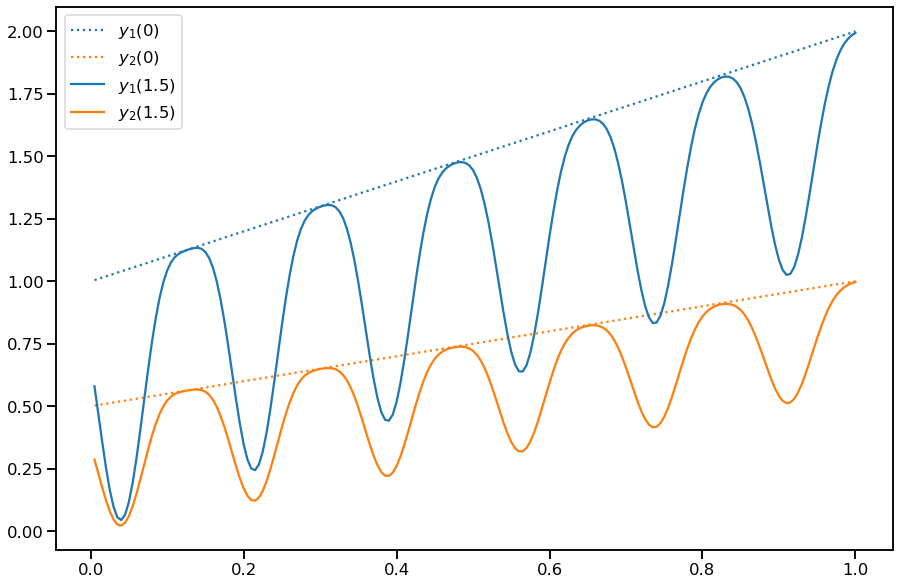

------------------------------------------
Current Method
Selected method type: ARK
Method coefficients:
A =
[[0.         0.         0.        ]
 [0.58578644 0.         0.        ]
 [0.5        0.5        0.        ]]
b =
[0.35355339 0.35355339 0.29289322]
c =
[0.         0.58578644 1.        ]
At =
[[0.         0.         0.        ]
 [0.         0.         0.        ]
 [0.60355339 0.60355339 0.5       ]]
bt =
[0.35355339 0.35355339 0.29289322]
ct =
[0.         0.         1.70710678]
------------------------------------------


In [7]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup={'mx':200,'n':2,'Flux':'linear-advection','Flux_c':1.,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':KAPPA,
                   's':np.asarray([0,1]),'alpha':np.asarray([1,0])}
rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection Reaction 1D',pde_problem_setup)#('Navier-Stokes2D')

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)


#solver.set_method('ARK2e')
#solver.set_method('ARK-IMEX-MR4')
solver.set_method('ARK-IMEX-Mix-2-2-c')


if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.002    
problem_setup['T_DURATION']['end']=TEND


print("CFL = {:}".format(pde_problem_setup['Flux_c']*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u,_,_,_=solver.get_trajectory_GLEE()
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))



#sol=u
unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
hy1=plt.plot(x_coord,y_ini[0,:],':',label=r'$y_1(0)$')
hy2=plt.plot(x_coord,y_ini[1,:],':',label=r'$y_2(0)$')

plt.plot(x_coord,y_end[0,:],'-',color=hy1[0].get_color(),label=r'$y_1({:g})$'.format(t[-1]))
plt.plot(x_coord,y_end[1,:],'-',color=hy2[0].get_color(),label=r'$y_2({:g})$'.format(t[-1]))

plt.legend()
plt.show()

solver.view_complete_status()

ARK22c={'x_coord':x_coord,'y_end':y_end}


CFL = 0.4
Solving Advection Reaction 1D by using ARK3


/opt/local/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Mass ini = 2.2542499999999994 and mass end = 1.6716957132794195


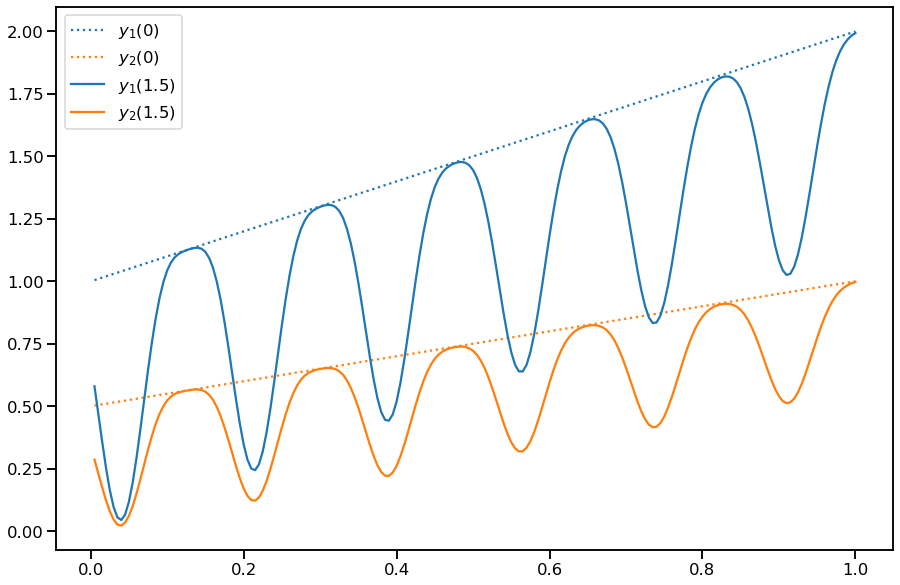

------------------------------------------
Current Method
Selected method type: ARK
Method coefficients:
A =
[[ 0.          0.          0.          0.        ]
 [ 0.87173304  0.          0.          0.        ]
 [ 0.52758901  0.07241099  0.          0.        ]
 [ 0.39909601 -0.43755765  1.03846165  0.        ]]
b =
[ 0.18764102 -0.59529747  0.97178993  0.43586652]
c =
[0.         0.87173304 0.6        1.        ]
At =
[[ 0.          0.          0.          0.        ]
 [ 0.43586652  0.43586652  0.          0.        ]
 [ 0.25764825 -0.09351477  0.43586652  0.        ]
 [ 0.18764102 -0.59529747  0.97178993  0.43586652]]
bt =
[ 0.18764102 -0.59529747  0.97178993  0.43586652]
ct =
[0.         0.87173304 0.6        1.        ]
------------------------------------------


In [8]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup={'mx':200,'n':2,'Flux':'linear-advection','Flux_c':1.,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':KAPPA,
                   's':np.asarray([0,1]),'alpha':np.asarray([1,0])}
rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection Reaction 1D',pde_problem_setup)#('Navier-Stokes2D')

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)


#solver.set_method('ARK2e')
#solver.set_method('ARK-IMEX-MR4')
solver.set_method('ARK3')


if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.002    
problem_setup['T_DURATION']['end']=TEND


print("CFL = {:}".format(pde_problem_setup['Flux_c']*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u,_,_,_=solver.get_trajectory_GLEE()
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))



#sol=u
unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
hy1=plt.plot(x_coord,y_ini[0,:],':',label=r'$y_1(0)$')
hy2=plt.plot(x_coord,y_ini[1,:],':',label=r'$y_2(0)$')

plt.plot(x_coord,y_end[0,:],'-',color=hy1[0].get_color(),label=r'$y_1({:g})$'.format(t[-1]))
plt.plot(x_coord,y_end[1,:],'-',color=hy2[0].get_color(),label=r'$y_2({:g})$'.format(t[-1]))

plt.legend()
plt.show()

solver.view_complete_status()

ARK33={'x_coord':x_coord,'y_end':y_end}

CFL = 0.4
Solving Advection Reaction 1D by using ARK-IMEX-Mix-3-1


/opt/local/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Mass ini = 2.2542499999999994 and mass end = 1.6717169096350442


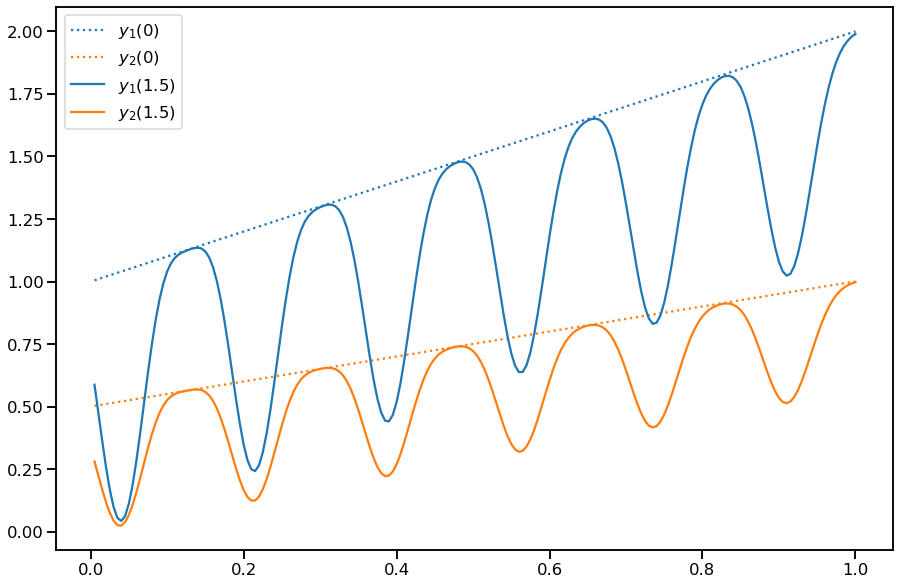

------------------------------------------
Current Method
Selected method type: ARK
Method coefficients:
A =
[[ 0.          0.          0.          0.        ]
 [ 0.87173304  0.          0.          0.        ]
 [ 0.52758901  0.07241099  0.          0.        ]
 [ 0.39909601 -0.43755765  1.03846165  0.        ]]
b =
[ 0.18764102 -0.59529747  0.97178993  0.43586652]
c =
[0.         0.87173304 0.6        1.        ]
At =
[[ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.43050112 -1.3657793   2.22955855  1.        ]]
bt =
[ 0.18764102 -0.59529747  0.97178993  0.43586652]
ct =
[0.         0.         0.         2.29428036]
------------------------------------------


In [9]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup={'mx':200,'n':2,'Flux':'linear-advection','Flux_c':1.,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':KAPPA,
                   's':np.asarray([0,1]),'alpha':np.asarray([1,0])}
rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection Reaction 1D',pde_problem_setup)#('Navier-Stokes2D')

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)


#solver.set_method('ARK2e')
#solver.set_method('ARK-IMEX-MR4')
solver.set_method('ARK-IMEX-Mix-3-1')


if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.002    
problem_setup['T_DURATION']['end']=TEND


print("CFL = {:}".format(pde_problem_setup['Flux_c']*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u,_,_,_=solver.get_trajectory_GLEE()
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))



#sol=u
unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
hy1=plt.plot(x_coord,y_ini[0,:],':',label=r'$y_1(0)$')
hy2=plt.plot(x_coord,y_ini[1,:],':',label=r'$y_2(0)$')

plt.plot(x_coord,y_end[0,:],'-',color=hy1[0].get_color(),label=r'$y_1({:g})$'.format(t[-1]))
plt.plot(x_coord,y_end[1,:],'-',color=hy2[0].get_color(),label=r'$y_2({:g})$'.format(t[-1]))

plt.legend()
plt.show()

solver.view_complete_status()

ARK31={'x_coord':x_coord,'y_end':y_end}

CFL = 0.4
Solving Advection Reaction 1D by using ARK4


/opt/local/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Mass ini = 2.2542499999999994 and mass end = 1.6716961841183298


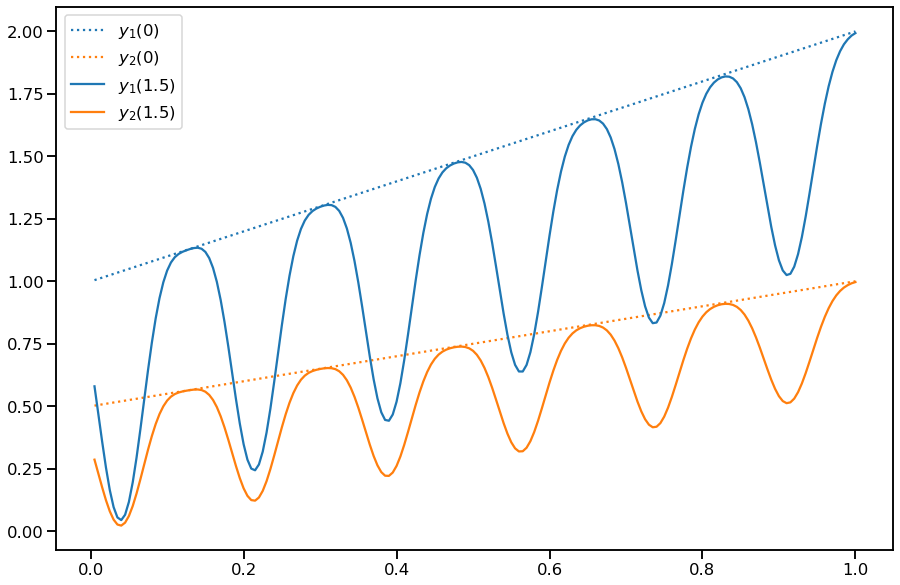

------------------------------------------
Current Method
Selected method type: ARK
Method coefficients:
A =
[[ 0.          0.          0.          0.          0.          0.        ]
 [ 0.5         0.          0.          0.          0.          0.        ]
 [ 0.221776    0.110224    0.          0.          0.          0.        ]
 [-0.0488466  -0.17772065  0.84656725  0.          0.          0.        ]
 [-0.15541686 -0.35670501  1.05872588  0.30339599  0.          0.        ]
 [ 0.20142435  0.00874206  0.15993996  0.40382906  0.22606457  0.        ]]
b =
[ 0.1579163   0.          0.18675894  0.6805653  -0.27524053  0.25      ]
c =
[0.    0.5   0.332 0.62  0.85  1.   ]
At =
[[ 0.          0.          0.          0.          0.          0.        ]
 [ 0.25        0.25        0.          0.          0.          0.        ]
 [ 0.137776   -0.055776    0.25        0.          0.          0.        ]
 [ 0.14463687 -0.22393191  0.44929504  0.25        0.          0.        ]
 [ 0.09825878 -

In [10]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup={'mx':200,'n':2,'Flux':'linear-advection','Flux_c':1.,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':KAPPA,
                   's':np.asarray([0,1]),'alpha':np.asarray([1,0])}
rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection Reaction 1D',pde_problem_setup)#('Navier-Stokes2D')

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)


#solver.set_method('ARK2e')
#solver.set_method('ARK-IMEX-MR4')
solver.set_method('ARK4')


if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.002    
problem_setup['T_DURATION']['end']=TEND


print("CFL = {:}".format(pde_problem_setup['Flux_c']*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u,_,_,_=solver.get_trajectory_GLEE()
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))



#sol=u
unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
hy1=plt.plot(x_coord,y_ini[0,:],':',label=r'$y_1(0)$')
hy2=plt.plot(x_coord,y_ini[1,:],':',label=r'$y_2(0)$')

plt.plot(x_coord,y_end[0,:],'-',color=hy1[0].get_color(),label=r'$y_1({:g})$'.format(t[-1]))
plt.plot(x_coord,y_end[1,:],'-',color=hy2[0].get_color(),label=r'$y_2({:g})$'.format(t[-1]))

plt.legend()
plt.show()

solver.view_complete_status()

ARK44={'x_coord':x_coord,'y_end':y_end}

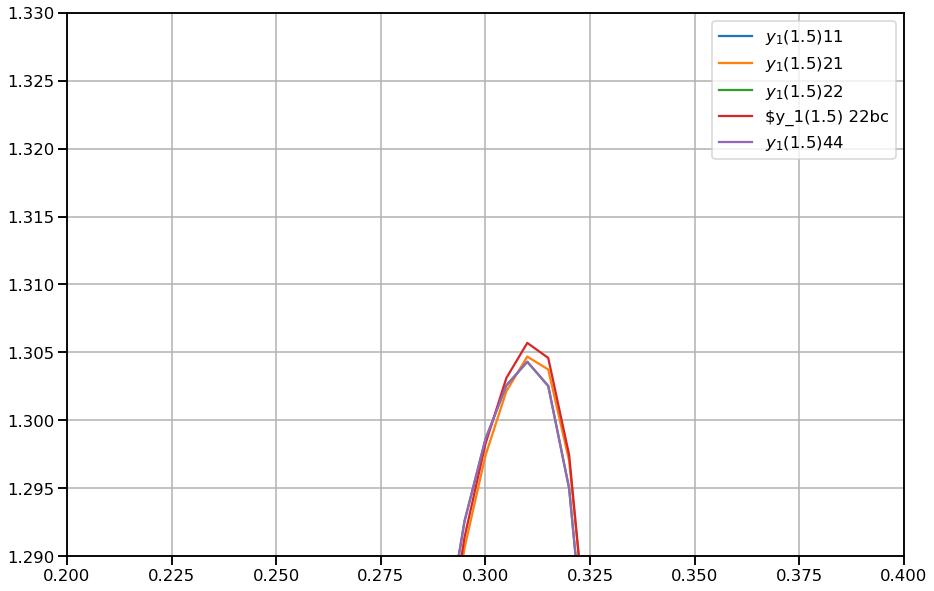

In [11]:
fig = plt.figure(figsize=(15, 10))
plt.plot(ARK11['x_coord'],ARK11['y_end'][0,:],'-',label=r'$y_1({:g}) 11$'.format(t[-1]))
plt.plot(ARK21['x_coord'],ARK21['y_end'][0,:],'-',label=r'$y_1({:g}) 21$'.format(t[-1]))
plt.plot(ARK22['x_coord'],ARK22['y_end'][0,:],'-',label=r'$y_1({:g}) 22$'.format(t[-1]))
plt.plot(ARK22c['x_coord'],ARK22c['y_end'][0,:],'-',label=r'$y_1({:g}) 22bc'.format(t[-1]))
plt.plot(ARK44['x_coord'],ARK22['y_end'][0,:],'-',label=r'$y_1({:g}) 44$'.format(t[-1]))
plt.ylim([1.29,1.33])
plt.xlim([.2,.4])
plt.grid('both')
plt.legend()
plt.show()

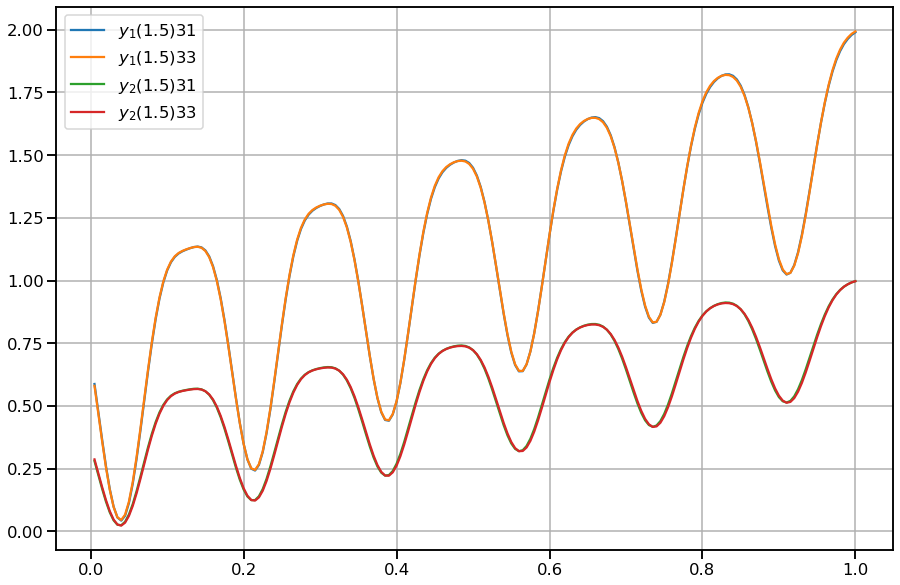

In [12]:
fig = plt.figure(figsize=(15, 10))
plt.plot(ARK31['x_coord'],ARK31['y_end'][0,:],'-',label=r'$y_1({:g}) 31$'.format(t[-1]))
plt.plot(ARK33['x_coord'],ARK33['y_end'][0,:],'-',label=r'$y_1({:g}) 33$'.format(t[-1]))
plt.plot(ARK31['x_coord'],ARK31['y_end'][1,:],'-',label=r'$y_2({:g}) 31$'.format(t[-1]))
plt.plot(ARK33['x_coord'],ARK33['y_end'][1,:],'-',label=r'$y_2({:g}) 33$'.format(t[-1]))

plt.grid('both')
plt.legend()
plt.show()

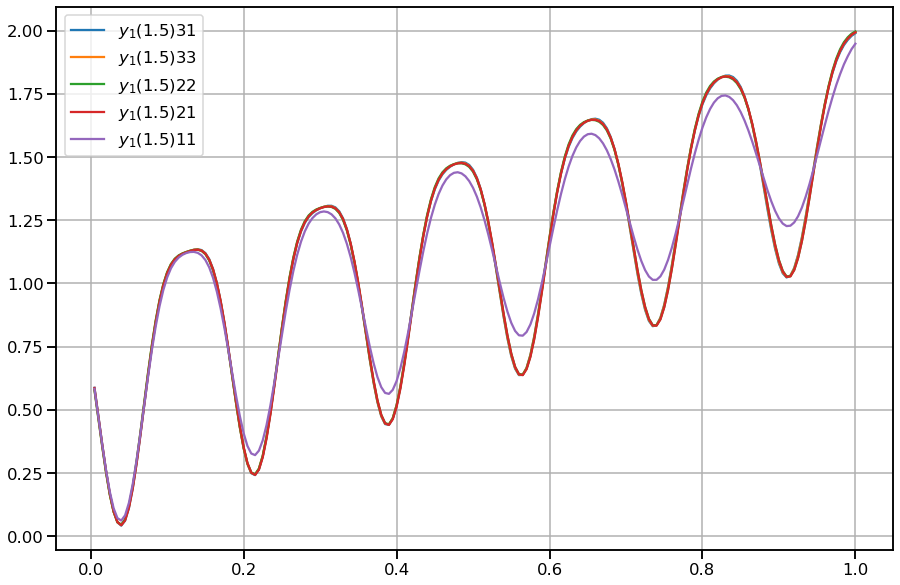

In [13]:
fig = plt.figure(figsize=(15, 10))
plt.plot(ARK31['x_coord'],ARK31['y_end'][0,:],'-',label=r'$y_1({:g}) 31$'.format(t[-1]))
plt.plot(ARK33['x_coord'],ARK33['y_end'][0,:],'-',label=r'$y_1({:g}) 33$'.format(t[-1]))

plt.plot(ARK22['x_coord'],ARK22['y_end'][0,:],'-',label=r'$y_1({:g}) 22$'.format(t[-1]))
plt.plot(ARK21['x_coord'],ARK21['y_end'][0,:],'-',label=r'$y_1({:g}) 21$'.format(t[-1]))

plt.plot(ARK11['x_coord'],ARK11['y_end'][0,:],'-',label=r'$y_1({:g}) 11$'.format(t[-1]))

plt.grid('both')
plt.legend()
plt.show()

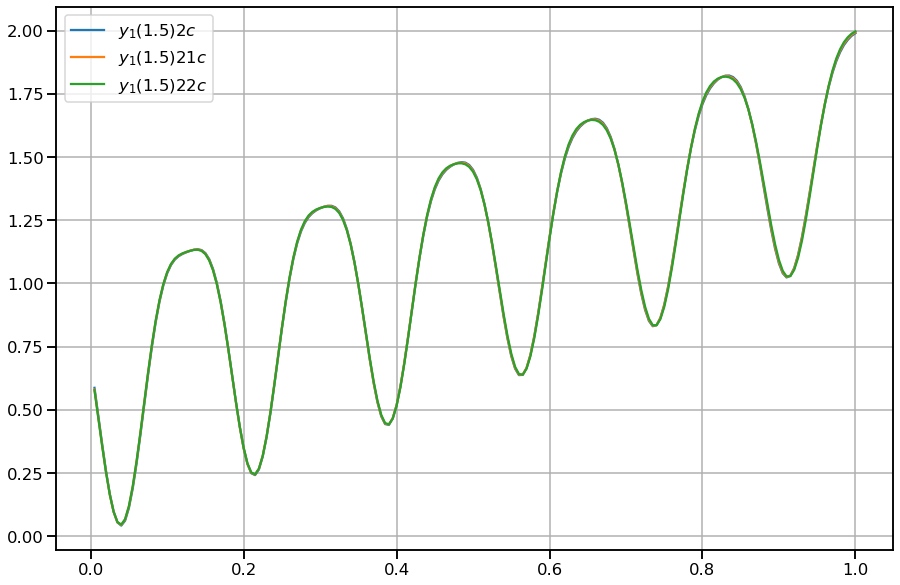

In [22]:
fig = plt.figure(figsize=(15, 10))
plt.plot(ARK2c['x_coord'],ARK31['y_end'][0,:],'-',label=r'$y_1({:g}) 2c$'.format(t[-1]))
plt.plot(ARK21c['x_coord'],ARK33['y_end'][0,:],'-',label=r'$y_1({:g}) 21c$'.format(t[-1]))
plt.plot(ARK22c['x_coord'],ARK22['y_end'][0,:],'-',label=r'$y_1({:g}) 22c$'.format(t[-1]))
plt.grid('both')
plt.legend()
plt.show()

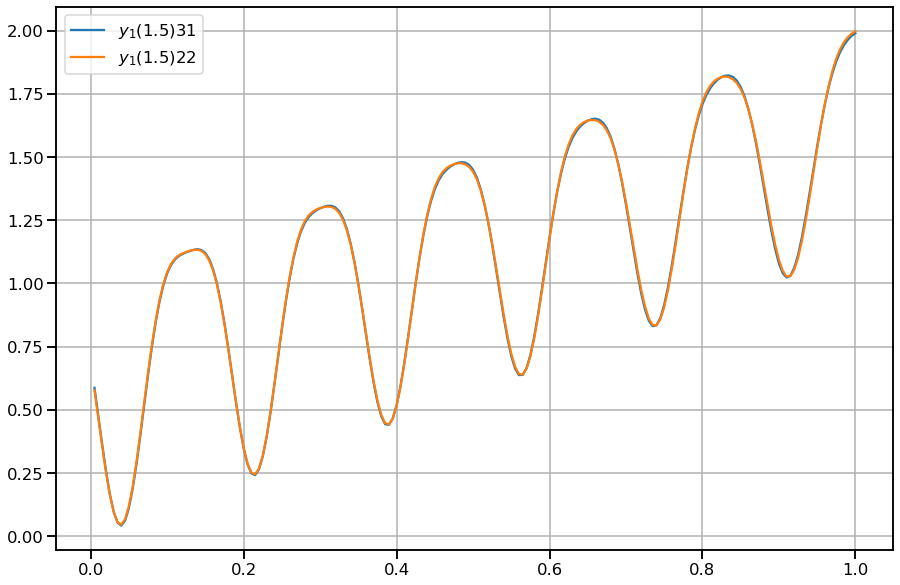

In [14]:
fig = plt.figure(figsize=(15, 10))
plt.plot(ARK31['x_coord'],ARK31['y_end'][0,:],'-',label=r'$y_1({:g}) 31$'.format(t[-1]))

plt.plot(ARK22['x_coord'],ARK22['y_end'][0,:],'-',label=r'$y_1({:g}) 22$'.format(t[-1]))


plt.grid('both')
plt.legend()
plt.show()

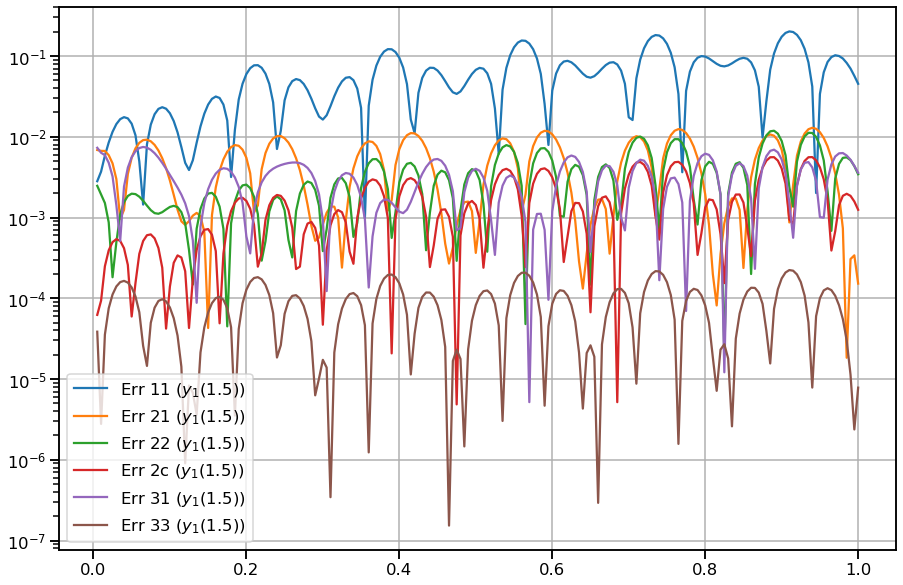

In [15]:
fig = plt.figure(figsize=(15, 10))
plt.plot(ARK31['x_coord'],np.sqrt((ARK44['y_end'][0,:]-ARK11['y_end'][0,:])**2),'-',label=r'Err 11 $(y_1({:g}))$'.format(t[-1]))

plt.plot(ARK31['x_coord'],np.sqrt((ARK44['y_end'][0,:]-ARK21['y_end'][0,:])**2),'-',label=r'Err 21 $(y_1({:g}))$'.format(t[-1]))
plt.plot(ARK31['x_coord'],np.sqrt((ARK44['y_end'][0,:]-ARK22['y_end'][0,:])**2),'-',label=r'Err 22 $(y_1({:g}))$'.format(t[-1]))
plt.plot(ARK31['x_coord'],np.sqrt((ARK44['y_end'][0,:]-ARK2c['y_end'][0,:])**2),'-',label=r'Err 2c $(y_1({:g}))$'.format(t[-1]))

plt.plot(ARK31['x_coord'],np.sqrt((ARK44['y_end'][0,:]-ARK31['y_end'][0,:])**2),'-',label=r'Err 31 $(y_1({:g}))$'.format(t[-1]))
plt.plot(ARK31['x_coord'],np.sqrt((ARK44['y_end'][0,:]-ARK33['y_end'][0,:])**2),'-',label=r'Err 33 $(y_1({:g}))$'.format(t[-1]))
plt.yscale('log')
plt.grid('both')
plt.legend()
plt.show()

In [16]:
np.linalg.norm((ARK44['y_end'][0,:]-ARK11['y_end'][0,:]),2)

1.0752170755641097

In [17]:
np.linalg.norm((ARK44['y_end'][0,:]-ARK21['y_end'][0,:]),2)

0.08801075620422075

In [18]:
np.linalg.norm((ARK44['y_end'][0,:]-ARK22['y_end'][0,:]),2)

0.06237445914730781

In [19]:
np.linalg.norm((ARK44['y_end'][0,:]-ARK2c['y_end'][0,:]),2)

0.031029945551043017

In [20]:
np.linalg.norm((ARK44['y_end'][0,:]-ARK31['y_end'][0,:]),2)

0.05146790740515125

In [21]:
np.linalg.norm((ARK44['y_end'][0,:]-ARK33['y_end'][0,:]),2)

0.0014456371202223807

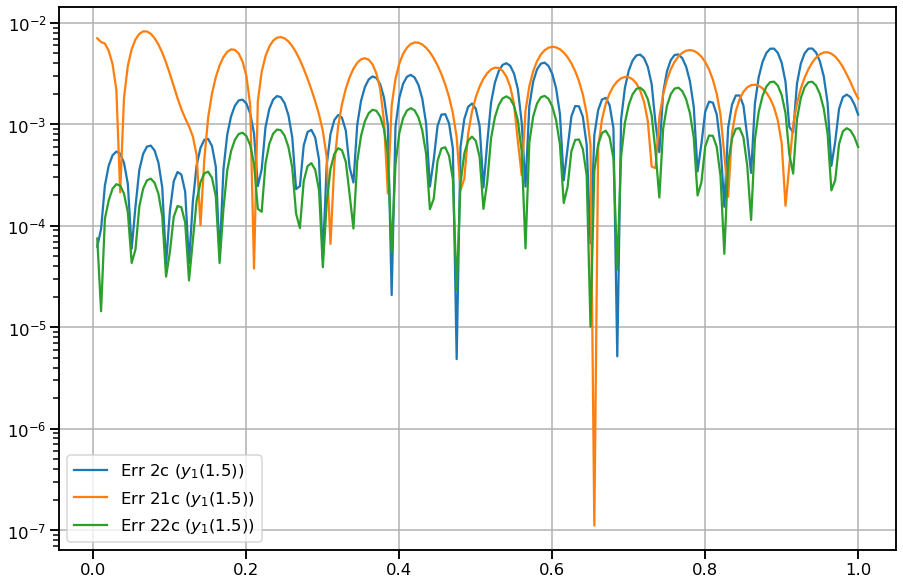

In [23]:
fig = plt.figure(figsize=(15, 10))
plt.plot(ARK31['x_coord'],np.sqrt((ARK44['y_end'][0,:]-ARK2c['y_end'][0,:])**2),'-',label=r'Err 2c $(y_1({:g}))$'.format(t[-1]))
plt.plot(ARK31['x_coord'],np.sqrt((ARK44['y_end'][0,:]-ARK21c['y_end'][0,:])**2),'-',label=r'Err 21c $(y_1({:g}))$'.format(t[-1]))
plt.plot(ARK31['x_coord'],np.sqrt((ARK44['y_end'][0,:]-ARK22c['y_end'][0,:])**2),'-',label=r'Err 22c $(y_1({:g}))$'.format(t[-1]))
plt.yscale('log')
plt.grid('both')
plt.legend()
plt.show()